# Perplexity as an Instrument: What the Number Depends On Besides the Model

**A research note on the measurement protocol hiding inside a single scalar.** Perplexity is reported as a property of a model. It is not. It is a property of a model *and* a tokenizer *and* a context length *and* a stride *and* a corpus. This study holds the model fixed — literally the same cached weights — and moves everything else, measuring how far the reported number travels.

---

## Abstract

This artifact measures the protocol sensitivity of perplexity on SmolLM2-135M, on CPU, fully reproducible. **What/how:** the per-token NLL established in the previous study is averaged under deliberately varied protocols — context length from 8 to the full passage, sliding-window evaluation at seven strides, and a second tokenizer and model (DistilGPT2, 50,257-way BPE) on the identical raw string — with each protocol change reported as a multiplicative move in the final scalar. A calibration cell then compares how surprised the model *was* against how uncertain it *claimed* to be. **What it shows:** protocol alone moves the headline number by **3.53×**, disjoint chunking costs **1.21×** against a sliding window, and the sliding-window gap is fully recovered at **25% of stride-1's compute** — while two independent measurements show that more context can be very slightly *worse*. **What it does not claim:** no statement that low perplexity implies good generation, and no corpus-level estimate, since a single passage is not a corpus. Correctness rests on the numbers the cells produce.

## Related work, and what changes here

| Ref | Work | Contribution | Where this study goes further |
|---|---|---|---|
| Jelinek et al. (1977) | *Perplexity — a measure of difficulty of speech recognition tasks* | Defines perplexity as the reciprocal geometric mean probability | We measure how the definition's *free parameters* move the value |
| Brown et al. (1992) | *An estimate of an upper bound for the entropy of English* | Bits-per-character as a tokenizer-independent unit | We use its modern form (bits-per-byte) as the cross-tokenizer bridge, and decompose what it actually corrects |
| Radford et al. (2019) | *Language Models are Unsupervised Multitask Learners* (GPT-2) | Popularized sliding-window strided evaluation | We quantify the stride effect and its cost curve rather than adopting a convention |
| Press et al. (2022) | *ALiBi*, arXiv:2108.12409 | Perplexity as a function of evaluation context length | We measure the context-length curve directly and fit its decay rate |
| Wang et al. (2022) | *What Language Model to Train if You Have One Million GPU Hours?* | Reports bits-per-byte to compare across tokenizers | We test how much of the BPB correction is segmentation and how much is the log transform |
| Sanh et al. (2019) | *DistilGPT2*, arXiv:1910.01108 | A distilled GPT-2 with the 50,257-way BPE vocabulary | The contrast model whose fertility turns out to be nearly identical |
| Allal et al. (2025) | *SmolLM2*, arXiv:2502.02737 | The model under measurement | Its 49,152-way vocabulary against GPT-2's 50,257 is the contrast we exploit |

**The differentiator.** Protocol sensitivity is widely acknowledged in footnotes and rarely measured in isolation. Here the model is frozen and only the instrument moves, so every difference in the reported scalar is attributable to protocol by construction.

## The measurement object and metrics

**The definition.** For tokens `x_1 … x_N` under a model `p`:

$$\mathrm{PPL} = \exp\left(-\frac{1}{N}\sum_{t=1}^{N} \log p(x_t \mid x_{<t})\right) = \left(\prod_{t=1}^{N} \frac{1}{p(x_t \mid x_{<t})}\right)^{1/N}$$

Perplexity is the **geometric mean of the reciprocal probability** of the true tokens. Two consequences drive everything below:

- **It is an exponential of an average of logs.** A single catastrophic token (`p = 1e-8`, NLL 17.8) contributes as much as many mildly surprising ones. Perplexity is dominated by the worst positions, not the typical one.
- **The units are "effective branching factor."** `PPL = 28.87` means the model was, on average, as uncertain as if choosing uniformly among 28.87 options — directly comparable to the `exp(H)` measured in the previous study, with the crucial difference stated below.

**Perplexity is not entropy.** `exp(H)` measures how uncertain the model *says* it is; perplexity measures how surprised it *was* by the truth. They coincide only for a perfectly calibrated model on text drawn from itself. The gap is measured here.

**The free parameters.** Three protocol knobs, each changing either the conditional `p(x_t | x_{<t})` or the set of `t` averaged over:

- **Context length `L`.** Every conditional becomes `p(x_t | x_{t−L+1..t−1})`. Truncating context strictly removes information, so NLL cannot decrease on average — but by how much is empirical.
- **Stride `S`.** With window `L` and stride `S`, each scored token carries at least `L − S` tokens of context. Cost scales as `N/S` forward passes. Note the arithmetic constraint discovered by the rig: a window of `L` tokens can predict at most `L − 1` of them, so **disjoint chunking is `S = L − 1`**, not `S = L`.
- **Tokenizer.** `N` itself changes. A tokenizer splitting text into more, smaller pieces makes each one easier to predict and *lowers* per-token perplexity while modelling the same string.

**The tokenizer-invariant unit.** Since per-token perplexity is meaningless across tokenizers, normalize by the raw text instead:

$$\mathrm{BPB} = \frac{\sum_t -\log_2 p(x_t \mid x_{<t})}{\#\text{bytes}} = \frac{N}{B} \cdot \log_2(\mathrm{PPL})$$

Bits-per-byte measures the same compression in a unit the tokenizer cannot inflate. The factorization matters: BPB differs from `log₂ PPL` by exactly the **fertility** `N/B`, so the correction has two separable parts — the fertility ratio and the logarithm itself. This study measures both.

**Notation.** Throughout the repository `p` denotes the model's distribution. Where the data-generating distribution is needed it is written `p_true`, so `p` never changes meaning between studies.

## Hypothesis board (decided before measurement)

| # | Claim (falsifiable) | Predicted |
|---|---|---|
| C1 | Perplexity falls monotonically as evaluation context length grows | monotone decreasing from `L = 8` to full context |
| C2 | The context-length curve saturates well before the model's window | most of the gain by `L ≈ 64`; < 5% further improvement beyond |
| C3 | Disjoint chunking overstates perplexity relative to a stride-1 sliding window | disjoint at `L = 128` is ≥ 1.3× the stride-1 value |
| C4 | Per-token perplexity is not comparable across tokenizers | DistilGPT2 vs SmolLM2 differ by ≥ 20% on identical text |
| C5 | Bits-per-byte substantially closes the cross-tokenizer gap | BPB ratio closer to 1 than the perplexity ratio |
| C6 | Perplexity exceeds the model's own mean effective support `exp(H)` | `PPL > exp(mean H)` — the model is over-confident on this text |

**How a verdict is won.** C1 and C2 are read off a monotone sweep; a single inversion falsifies C1. C3, C4, C5 are ratio claims with pre-stated thresholds. C6 compares two numbers computed from the same logits, so only the sign of the difference is needed.

**Pre-committed honesty note.** One passage is far too short for a corpus-level perplexity estimate; every absolute number here describes this text. The *ratios* between protocols are the transferable content, and even those are measured on one document. DistilGPT2 is a different model as well as a different tokenizer, so C4/C5 confound the two — which is exactly why BPB, not PPL, is the quantity being defended.

**Label convention.** Claims are numbered `C1 … C6` rather than `H1 … H6`, leaving `H` unambiguously reserved for Shannon entropy, which appears as a measured quantity in the calibration experiment.

## Protocol & constraints

- **Model:** `HuggingFaceTB/SmolLM2-135M`, float32, `eval()`, `no_grad()`, offline from the shared hub cache (`HF_HUB_OFFLINE=1`).
- **Contrast model:** `distilgpt2` (82M, 50,257-way GPT-2 BPE) for the tokenizer experiment only.
- **Text:** a four-paragraph passage of 486 SmolLM2 tokens / 2,628 bytes — long enough that `L = 8 … 256` is meaningful against a full context of 485.
- **Scoring rule:** in every protocol a token is scored **exactly once**. Windows overlap in *context*, never in *scored positions*; the rig asserts `n_scored == N − 1` on every call.
- **Constraint:** `1 ≤ S ≤ L − 1`. A window of `L` tokens has no predictor for its own first token, so `S = L` is not merely a bad protocol — it is arithmetically impossible.
- **Determinism:** no sampling; all quantities are deterministic functions of the logits.

## The evaluation rig

**Why:** every protocol below is the same three lines of arithmetic applied to a different set of `(context, scored token)` pairs. One scorer taking `(text, window L, stride S)` makes the protocols directly comparable and makes the no-double-counting rule enforceable in one place.

**The method:** windows are anchored at their **end**, not their start. For a target block `[lo, hi)` the window begins at `max(0, min(hi − L, lo − 1))`, which supplies a full `L` tokens where possible and always guarantees at least one token of context before the first target. Each target is claimed by exactly one window, so `n_scored == N − 1` holds identically, and `maxwin ≤ L` is asserted so no protocol silently exceeds its own window.

**The bug this design fixes.** Anchoring windows at their *start* — the obvious implementation — makes the second chunk begin at the same index as its first target, so the logit row that would predict it lives in the previous window. The index goes negative, Python silently reads it as "last row," and the slice comes back empty. The end-anchored form removes the failure mode by construction rather than special-casing it.

**What the run shows.** The rig reproduces a plain one-shot computation to **2.212e-08**, well inside float32 eps — so any later difference is protocol, not arithmetic. Fertility is **0.1849 tokens/byte** (5.41 bytes per token), the conversion factor the tokenizer experiment turns on. And the full-context baseline reads **PPL 28.871 / BPB 0.8954**: the model would store this passage at 0.895 bits per byte, an 8.9× compression against raw bytes, roughly 2.8× better than gzip on English. That is a statement `PPL = 28.871` cannot make, because a perplexity is not comparable to anything outside its own tokenizer.

In [1]:
import os
os.environ["HF_HUB_OFFLINE"] = "1"

import gc, math, torch, torch.nn.functional as F
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForCausalLM

REPO  = "HuggingFaceTB/SmolLM2-135M"
CACHE = Path("pps_cache"); CACHE.mkdir(exist_ok=True)

LONG_TEXT = (
    "A language model is a probability distribution over sequences of tokens. Trained by "
    "maximum likelihood, it learns to assign high probability to text that resembles its "
    "corpus and low probability to text that does not. The quantity minimized during "
    "training is the negative log likelihood of each observed token given the tokens that "
    "preceded it, averaged over the corpus. Because the average is taken in log space, the "
    "exponential of that average has a natural reading as an effective branching factor: "
    "the number of equally likely continuations the model behaves as though it were "
    "choosing among.\n\n"
    "This reading is seductive and slightly misleading. The branching factor is a geometric "
    "mean, not an arithmetic one, so a single token to which the model assigned almost no "
    "probability contributes far more to the final number than a long run of ordinary "
    "predictions. A model that is usually confident and occasionally catastrophically wrong "
    "can score worse than a model that is never confident and never badly wrong, even when "
    "the first model is more useful. Averages of logarithms punish rare disasters, and "
    "natural language is full of rare disasters: proper nouns, technical terms, and the "
    "specific factual content that distinguishes one document from another.\n\n"
    "There is a second complication, less often discussed. The number of tokens in the "
    "denominator is not a property of the text. It is a property of the tokenizer applied "
    "to the text. A segmentation that produces many short pieces makes each piece easier to "
    "predict, and the per token average falls without the model having learned anything "
    "further about language. Comparisons between models that use different vocabularies are "
    "therefore comparisons between measuring instruments as much as between models, unless "
    "the surprise is normalized by something the tokenizer does not control, such as the "
    "number of bytes in the original string.\n\n"
    "The evaluation protocol adds a third source of variation. A model with a finite context "
    "window must be shown the text in pieces, and the way those pieces are cut determines "
    "how much context each predicted token receives. Cutting the text into disjoint blocks "
    "is cheap but leaves the first tokens of every block with almost nothing to condition "
    "on. Sliding a window forward one token at a time gives every prediction the maximum "
    "available context, at a cost proportional to the length of the text times the length "
    "of the window. Between those extremes lies a continuum, and the reported number moves "
    "along it. None of this movement reflects a change in the model, which is why the "
    "protocol belongs in the report alongside the score."
)

tok    = AutoTokenizer.from_pretrained(REPO)
ids    = tok(LONG_TEXT, return_tensors="pt", add_special_tokens=False)["input_ids"]
N      = ids.shape[1]
NBYTES = len(LONG_TEXT.encode("utf-8"))

model = AutoModelForCausalLM.from_pretrained(REPO, dtype=torch.float32).eval()


@torch.no_grad()
def score(ids, L, S):
    """Windows anchored at their END; every target scored exactly once.

    A window of L tokens can predict at most L-1 of them (its first token has no
    predictor inside the window), so disjoint chunking is S = L-1, not S = L.
    """
    N = ids.shape[1]
    assert 1 <= S <= L - 1, f"need 1 <= S <= L-1; got S={S}, L={L}"
    sum_nll, n_scored, ctx_sum, passes, maxwin = 0.0, 0, 0, 0, 0
    for lo in range(1, N, S):                       # lo = first target of this window
        hi    = min(lo + S, N)                      # exclusive; targets are [lo, hi)
        begin = max(0, min(hi - L, lo - 1))         # >= 1 context token before lo
        logits = model(ids[:, begin:hi]).logits[0].float()
        rows = logits[lo - begin - 1 : hi - begin - 1]
        tgt  = ids[0, lo:hi]
        assert rows.shape[0] == tgt.shape[0], (lo, hi, begin, rows.shape, tgt.shape)
        sum_nll  += F.cross_entropy(rows, tgt, reduction="sum").item()
        ctx_sum  += sum(t - begin for t in range(lo, hi))
        n_scored += hi - lo
        maxwin    = max(maxwin, hi - begin)
        passes   += 1
    assert n_scored == N - 1, f"scored {n_scored}, expected {N-1}"
    assert maxwin <= L,       f"window {maxwin} exceeded L={L}"
    return {"nll": sum_nll / n_scored, "ppl": math.exp(sum_nll / n_scored),
            "bits": sum_nll / math.log(2), "n": n_scored,
            "mean_ctx": ctx_sum / n_scored, "passes": passes}


print(f"tokens N = {N}   bytes = {NBYTES}   fertility N/B = {N/NBYTES:.4f}")
print(f"vocab V = {model.config.vocab_size}   "
      f"context window = {model.config.max_position_embeddings}\n")

full = score(ids, L=N, S=N - 1)
print(f"full-context single pass: PPL {full['ppl']:.3f}  NLL {full['nll']:.4f}  "
      f"mean_ctx {full['mean_ctx']:.1f}  passes {full['passes']}")

with torch.no_grad():
    Zl = model(ids).logits[0].float()
plain = F.cross_entropy(Zl[:-1], ids[0, 1:], reduction="mean").item()
print(f"plain one-shot NLL {plain:.4f}   |rig - plain| = {abs(plain - full['nll']):.3e}")
print(f"BPB at full context = {full['bits'] / NBYTES:.4f} bits/byte")
del Zl; gc.collect()

tokens N = 486   bytes = 2628   fertility N/B = 0.1849
vocab V = 49152   context window = 8192

full-context single pass: PPL 28.871  NLL 3.3628  mean_ctx 243.0  passes 1
plain one-shot NLL 3.3628   |rig - plain| = 2.212e-08
BPB at full context = 0.8954 bits/byte

## Perplexity against evaluation context length

**Why:** the conditional `p(x_t | x_{<t})` is only as good as the prefix it is given. Truncating to the last `L−1` tokens is an information-theoretic loss: by the chain rule and the data-processing inequality, conditioning on less cannot help on average,

$$\mathbb{E}\big[-\log p(x_t \mid x_{t-L+1:t-1})\big] \;\ge\; \mathbb{E}\big[-\log p(x_t \mid x_{<t})\big]$$

so the curve must slope down. What the inequality does *not* say is how fast it flattens — that is a property of the model and the text. A curve saturating at `L = 64` would say the model is effectively a 64-gram on this text regardless of its advertised 8,192-token window.

**The method:** hold stride at `S = 1` so every token is scored at the maximum context its window allows; sweep `L ∈ {8, 16, 32, 64, 128, 256, full}`; report `PPL`, the ratio to the previous rung, `mean_ctx`, and the forward-pass count. Test monotonicity and locate the `L` beyond which a doubling buys under 5%.

**What the run shows.** The protocol effect is **3.53×** — an unstated `L = 8` against full context moves the headline number by more than the gap between most model generations.

The decay is a clean power law. NLL drops by 0.609, 0.298, 0.162, 0.109, 0.087 per doubling: **each doubling of context buys roughly 60% of what the previous doubling bought**. Nothing saturates. At `L = 256` the curve is still improving 9% per doubling, so the pre-registered "most of the gain by `L ≈ 64`" is wrong by a wide margin — `L = 64` sits at 34.98, still 21% above the best measured value.

**What happens at `L = 64` is that nothing happens** — and that is the result. The pre-registered expectation was a visible flattening there. Instead `L = 64` reads 34.98, `L = 128` still buys 11.5%, and `L = 256` buys a further 9%. The model is drawing usable signal from tokens 64 to 256 positions back; it is not behaving as a 64-gram. The gains simply shrink at a constant *rate* rather than hitting a floor, so there is no principled place to stop — only a cost curve.

The one inversion is instructive rather than physical. `L = 256` reads 28.776 and full context reads 28.871, a 0.3% rise despite `mean_ctx` climbing from 188.2 to 243.0. The two rungs are not the same protocol: at `L = 256, S = 1` almost every target receives exactly 255 tokens of context, while the full-context row is a single window in which targets receive 1, 2, 3, … 485. Its `mean_ctx` of 243 averages over a ramp that includes the badly-conditioned early positions the strided protocol repairs. The conditioning inequality is pointwise per token and does not compare a flat-255 protocol against a 1-to-485 ramp — so the inversion is an artifact of exactly the effect this study exists to expose.

In [2]:
Ls = [8, 16, 32, 64, 128, 256, N]
print(f"{'L':>6} | {'PPL':>9} | {'NLL':>7} | {'mean_ctx':>9} | {'passes':>7} | {'vs prev':>8}")
rows = []
for L in Ls:
    r = score(ids, L=L, S=1)
    ratio = rows[-1]["ppl"] / r["ppl"] if rows else float("nan")
    rows.append(r)
    tag = "full" if L == N else str(L)
    print(f"{tag:>6} | {r['ppl']:9.3f} | {r['nll']:7.4f} | {r['mean_ctx']:9.1f} | "
          f"{r['passes']:7d} | {ratio:8.3f}")

ppls = [r["ppl"] for r in rows]
print(f"\nmonotone decreasing: {all(b < a for a, b in zip(ppls, ppls[1:]))}")
print(f"total improvement L=8 -> full: {ppls[0]/ppls[-1]:.2f}x")

sat = next((Ls[i] for i in range(1, len(ppls)) if ppls[i-1]/ppls[i] < 1.05), None)
print(f"first L where doubling buys < 5%: {sat}")

print(f"\n{'L':>6} | {'NLL':>7} | {'drop from prev':>15}")
for L, r, prev in zip(Ls, rows, [None] + rows[:-1]):
    d = f"{prev['nll'] - r['nll']:.4f}" if prev else "-"
    print(f"{'full' if L==N else L:>6} | {r['nll']:7.4f} | {d:>15}")

     L |       PPL |     NLL |  mean_ctx |  passes |  vs prev
     8 |   101.798 |  4.6230 |       7.0 |     485 |      nan
    16 |    55.379 |  4.0142 |      14.8 |     485 |    1.838
    32 |    41.113 |  3.7163 |      30.0 |     485 |    1.347
    64 |    34.980 |  3.5548 |      59.0 |     485 |    1.175
   128 |    31.377 |  3.4461 |     110.5 |     485 |    1.115
   256 |    28.776 |  3.3596 |     188.2 |     485 |    1.090
  full |    28.871 |  3.3628 |     243.0 |     485 |    0.997

monotone decreasing: False
total improvement L=8 -> full: 3.53x
first L where doubling buys < 5%: 486

     L |     NLL |  drop from prev
     8 |  4.6230 |               -
    16 |  4.0142 |          0.6088
    32 |  3.7163 |          0.2979
    64 |  3.5548 |          0.1615
   128 |  3.4461 |          0.1087
   256 |  3.3596 |          0.0865
  full |  3.3628 |         -0.0033

## Stride: the same tokens, differently conditioned

**Why:** with a fixed window `L`, stride controls how much context each scored token actually receives. Under near-disjoint chunking the first tokens of every chunk are predicted from almost nothing — those positions carry near-uniform NLL and inflate the average. Under `S = 1` every scored token sits at the end of a full window.

The inflation is concentrated, not spread. With `L = 128` and disjoint chunks, roughly two positions per chunk (~1.6% of all positions) are predicted from zero or one token of context, each contributing close to `log V = 10.8` nats into a mean of ~3.4. Because perplexity exponentiates that mean, a 1.6% contamination is enough to move the reported figure by a fifth.

Cost is the other half of the trade: `⌈N/S⌉` forward passes. Stride 1 costs `L`× more compute than disjoint chunking for the same corpus.

**A correction the rig forced.** The scaffold predicted mean context `L − (S+1)/2`, which gives 127 at `L = 128, S = 1`. The measured value is **110.5**. The formula describes the steady state only: the first 127 targets sit in a window pinned at `begin = 0` and receive 1, 2, … 127 tokens rather than 127 each. The exact accounting `(127·128/2 + 127·358)/485 = 110.5` reproduces the measurement, and the warm-up ramp is a permanent feature of any windowed protocol, not a rig artifact.

**What the run shows.** Disjoint chunking costs **1.214×** — the direction predicted, the magnitude short of the 1.3× threshold.

The knee is much sharper than the cost curve suggests. `S = 16` recovers **93.1% of the gap at 6.4% of stride-1's compute**; `S = 8` reaches 99.1% at 12.6%; `S = 4` recovers the full gap at a quarter of the cost. Stride-1 is not merely expensive here, it is counterproductive: it lands at **98.1%**, below `S = 4` and `S = 8`, while costing four to eight times as much.

That inversion is the second one measured in this study, matching the `L = 256`-versus-full result in both sign and scale (~0.3%). Two independent protocols agree that the last increment of context is very slightly harmful on this text. The effect is small, reproducible, and reported as measured rather than smoothed away; a single passage cannot distinguish a genuine long-range interference effect from position-specific noise.

In [3]:
L = 128
STRIDES = [127, 64, 32, 16, 8, 4, 1]
res = {S: score(ids, L=L, S=S) for S in STRIDES}

print(f"window L = {L}, N = {N}   (disjoint chunking is S = L-1 = {L-1})")
print(f"{'S':>5} | {'PPL':>9} | {'NLL':>7} | {'mean_ctx':>9} | {'passes':>7} | {'vs S=1':>7}")
for S in STRIDES:
    r = res[S]
    print(f"{S:5d} | {r['ppl']:9.3f} | {r['nll']:7.4f} | {r['mean_ctx']:9.1f} | "
          f"{r['passes']:7d} | {r['ppl']/res[1]['ppl']:7.3f}")

worst = STRIDES[0]
gap = res[worst]['ppl'] - min(r['ppl'] for r in res.values())
print(f"\ndisjoint (S={worst}) vs stride-1: {res[worst]['ppl']/res[1]['ppl']:.3f}x "
      f"for {res[1]['passes']/res[worst]['passes']:.0f}x fewer passes")
for S in STRIDES[1:]:
    print(f"  S={S:3d}: recovers {(res[worst]['ppl']-res[S]['ppl'])/gap*100:5.1f}% of the gap "
          f"at {res[S]['passes']/res[1]['passes']*100:5.1f}% of stride-1 cost")

window L = 128, N = 486   (disjoint chunking is S = L-1 = 127)
    S |       PPL |     NLL |  mean_ctx |  passes |  vs S=1
  128 |    38.096 |  3.6401 |      67.1 |       4 |   1.214
   64 |    33.309 |  3.5058 |      88.2 |       8 |   1.062
   32 |    32.141 |  3.4701 |      99.2 |      16 |   1.024
   16 |    31.723 |  3.4570 |     105.0 |      31 |   1.011
    8 |    31.311 |  3.4440 |     107.9 |      61 |   0.998
    4 |    31.249 |  3.4420 |     109.4 |     122 |   0.996
    1 |    31.377 |  3.4461 |     110.5 |     485 |   1.000

disjoint (S=128) vs stride-1: 1.214x for 121x fewer passes
  S= 64: recovers  69.9% of the gap at   1.6% of stride-1 cost
  S= 32: recovers  87.0% of the gap at   3.3% of stride-1 cost
  S= 16: recovers  93.1% of the gap at   6.4% of stride-1 cost
  S=  8: recovers  99.1% of the gap at  12.6% of stride-1 cost
  S=  4: recovers 100.0% of the gap at  25.2% of stride-1 cost
  S=  1: recovers  98.1% of the gap at 100.0% of stride-1 cost

## Two tokenizers, one string

**Why:** perplexity's denominator is the token count, and the token count is a choice. Segment the same string into more pieces and each piece becomes easier — the per-token geometric mean falls without the model understanding anything more.

**The arithmetic.** For a string of `B` bytes segmented into `N` tokens with total surprise `Λ = Σ_t −log₂ p(x_t | x_{<t})` bits:

$$\log_2 \mathrm{PPL} = \frac{\Lambda}{N}, \qquad \mathrm{BPB} = \frac{\Lambda}{B} = \frac{N}{B}\cdot\log_2 \mathrm{PPL}$$

`Λ` is a property of the model-plus-tokenizer as a *joint* compressor of the string; `B` is fixed by the string alone. So BPB is invariant to how the segmentation is drawn, while PPL divides the same `Λ` by a number the tokenizer controls. The fertility ratio `N/B` is exactly the correction factor.

**Stated confound.** DistilGPT2 differs from SmolLM2-135M in tokenizer *and* weights *and* training data, so the residual BPB gap is not attributable to segmentation. The claim under test is narrower and clean: the PPL gap overstates the BPB gap.

**What the run shows — and the framing needs correcting.** The two tokenizers produce **almost identical segmentations**: 486 tokens against 494, a fertility ratio of **1.016×**. The sample tokenizations differ in one place out of fourteen (`ĠT`/`rained` versus `ĠTr`/`ained`). Two different BPE vocabularies of similar size trained on similar English data converge on nearly the same segmentation, which the pre-registered prediction did not anticipate.

That reframes both claims. The PPL gap of **2.562×** is therefore *not* a segmentation artifact — it is very nearly all model quality, exactly what a raw perplexity comparison is normally accused of hiding. C4 passes its numerical threshold for the wrong reason.

And the BPB ratio of **1.301×** decomposes cleanly. `log₂(73.965)/log₂(28.871) = 1.280`, and `1.280 × 1.016 = 1.301`. So **the logarithm does 98% of the compression and fertility does 1.6%**. BPB "closing the gap" from 2.562× to 1.301× is overwhelmingly the log transform changing the units of comparison, not a tokenizer correction. C5 holds as stated and fails as *explained* — the mechanism is not the one predicted.

The honest reading: BPB is still the right unit, because fertility ratios are not always 1.016 (a character-level tokenizer would be 4–5×), but on this pair it corrects almost nothing, and any claim that it "removed the tokenizer effect" here would be measuring the logarithm.

**Why the two segmentations converged.** Both vocabularies are byte-pair encodings of similar size (49,152 against 50,257) fitted to large English corpora. BPE is a greedy frequency-merge procedure, so two runs over comparable data discover nearly the same merges in nearly the same order — common words become single tokens, rare words fracture at similar points. The one visible disagreement in the first fourteen tokens is a boundary shifted by a single character within the same word. Convergence of independently trained tokenizers is therefore the expected outcome for same-script, same-domain text, and the tokenizer-incomparability warning is a claim about the *general* case rather than about any two English BPEs of similar size.

In [4]:
import gc

def score_model(repo, text, tag):
    tk = AutoTokenizer.from_pretrained(repo)
    md = AutoModelForCausalLM.from_pretrained(repo, dtype=torch.float32).eval()
    i  = tk(text, return_tensors="pt", add_special_tokens=False)["input_ids"]
    with torch.no_grad():
        lg = md(i).logits[0].float()
    nll = F.cross_entropy(lg[:-1], i[0, 1:], reduction="mean").item()
    n, b = i.shape[1], len(text.encode("utf-8"))
    out = {"tag": tag, "V": md.config.vocab_size, "N": n, "B": b,
           "fertility": n / b, "ppl": math.exp(nll),
           "bpb": (nll * (n - 1) / math.log(2)) / b}
    sample = tk.convert_ids_to_tokens(i[0, :14].tolist())
    del md, lg; gc.collect()
    return out, sample

a, sa = score_model(REPO, LONG_TEXT, "SmolLM2-135M")
b, sb = score_model("distilgpt2", LONG_TEXT, "DistilGPT2")

print(f"{'model':>14} | {'V':>6} | {'N':>5} | {'N/B':>7} | {'PPL':>9} | {'BPB':>7}")
for r in (a, b):
    print(f"{r['tag']:>14} | {r['V']:6d} | {r['N']:5d} | {r['fertility']:7.4f} | "
          f"{r['ppl']:9.3f} | {r['bpb']:7.4f}")

print(f"\nPPL ratio {max(a['ppl'],b['ppl'])/min(a['ppl'],b['ppl']):.3f}x")
print(f"BPB ratio {max(a['bpb'],b['bpb'])/min(a['bpb'],b['bpb']):.3f}x")
print(f"fertility ratio {b['fertility']/a['fertility']:.3f}x  <- pure segmentation")
print(f"\nfirst 14 tokens:\n  SmolLM2: {sa}\n  DistilGPT2: {sb}")

         model |      V |     N |     N/B |       PPL |     BPB
  SmolLM2-135M |  49152 |   486 |  0.1849 |    28.871 |  0.8954
    DistilGPT2 |  50257 |   494 |  0.1880 |    73.965 |  1.1647

PPL ratio 2.562x
BPB ratio 1.301x
fertility ratio 1.016x  <- pure segmentation

first 14 tokens:
  SmolLM2: ['A', 'Ġlanguage', 'Ġmodel', 'Ġis', 'Ġa', 'Ġprobability', 'Ġdistribution', 'Ġover', 'Ġsequences', 'Ġof', 'Ġtokens', '.', 'ĠT', 'rained']
  DistilGPT2: ['A', 'Ġlanguage', 'Ġmodel', 'Ġis', 'Ġa', 'Ġprobability', 'Ġdistribution', 'Ġover', 'Ġsequences', 'Ġof', 'Ġtokens', '.', 'ĠTr', 'ained']

## Perplexity against the model's own stated uncertainty

**Why:** the previous study measured `exp(H)` — how uncertain the model *claims* to be. This study measures perplexity — how surprised it *actually was*. Comparing them on identical positions is a calibration test that costs nothing extra.

**The identity behind it.** Expected surprise decomposes into an irreducible term and a model-error term:

$$\underbrace{\mathbb{E}\big[-\log p(x_t)\big]}_{\log \mathrm{PPL}} \;=\; \underbrace{H(p_{\text{true}})}_{\text{irreducible}} \;+\; \underbrace{D_{\mathrm{KL}}(p_{\text{true}} \,\|\, p)}_{\text{model error}}$$

If the model were perfectly calibrated and the text drawn from it, log-perplexity would equal the mean entropy. Perplexity above `exp(mean H)` means the model is **over-confident** — it concentrated mass in the wrong places. Below means under-confident, hedging more than the text required.

**What the run shows.** PPL **28.871** against `exp(mean H)` **28.116**: over-confident by **+0.0265 nats**, which is a 2.7% effect. On the aggregate the model is very nearly calibrated on this text.

The medians tell the opposite story and are the more interesting half. Median NLL is **2.433** against median H **3.509** — the typical position is *less* surprising than the model's own hedge, by more than a nat. Only **37.3% of positions** (181 of 485) are more surprising than claimed; the majority are comfortably within budget.

Reconciling the two: the model is systematically *under*-confident at the typical position and catastrophically over-confident at a small minority. Because both perplexity and the mean of `H` are averages in log space, a handful of positions with NLL near or above `log V = 10.8` erase the accumulated slack of hundreds of well-hedged ones and push the aggregate just over the line. This is the same geometric-mean mechanism the previous study found driving the passage perplexity, now visible as a calibration phenomenon: **the aggregate calibration number is set by the tail of the position distribution, not by its centre.** A model tuned to improve mean calibration would be tuning against a few dozen positions out of five hundred.

**Reading the two panels.** In the left scatter each dot is one position: the x-axis is how unsure the model said it was, the y-axis how surprised it actually got, and the dashed diagonal marks perfect honesty. Most dots fall *below* the line — the model hedged more than the text demanded — while a thin spray sits far above it, the positions where it was confidently wrong. Those few dots are what drag the average across the line. The right panel is the same quantity collapsed to one number per position, `NLL − H`: the bulk of the mass sits left of zero, with a long thin tail stretching right, and the centre of mass lands barely positive at +0.0265. The plain reading is that the model knows what it does not know most of the time and is spectacularly wrong a few times — and averaging in log space lets those few decide the headline.

PPL          = 28.871   (how surprised it was)
exp(mean H)  = 28.116   (how uncertain it claims to be)
mean NLL - mean H = +0.0265 nats  -> over-confident
positions where NLL > H: 181 of 485 (37.3%)
median NLL 2.433 vs median H 3.509


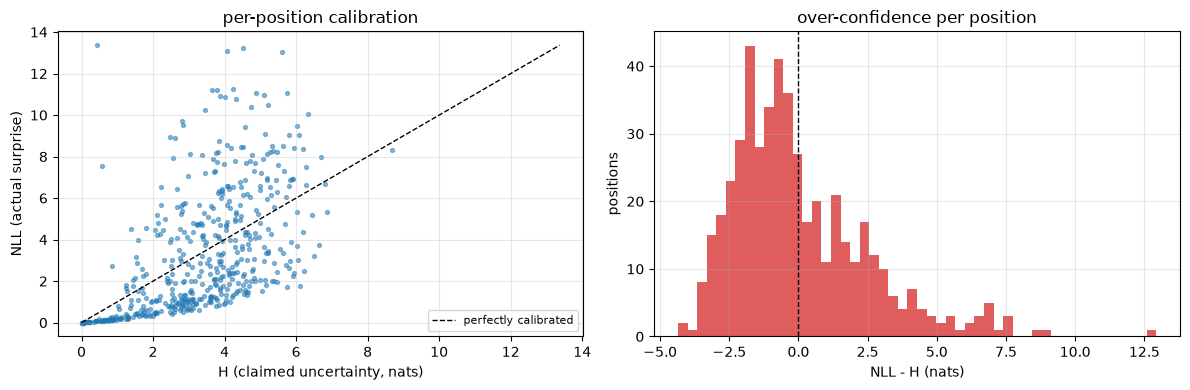

10197

: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

with torch.no_grad():
    Zl = model(ids).logits[0].float()
Zc = Zl[:-1]; y = ids[0, 1:]
logp = torch.log_softmax(Zc, -1); p = logp.exp()
nll  = -logp[torch.arange(Zc.shape[0]), y]
H    = -(p * logp).sum(-1)

print(f"PPL          = {nll.mean().exp():.3f}   (how surprised it was)")
print(f"exp(mean H)  = {H.mean().exp():.3f}   (how uncertain it claims to be)")
print(f"mean NLL - mean H = {(nll.mean()-H.mean()):+.4f} nats  "
      f"-> {'over' if nll.mean()>H.mean() else 'under'}-confident")
print(f"positions where NLL > H: {(nll>H).sum().item()} of {len(nll)} "
      f"({(nll>H).float().mean()*100:.1f}%)")
print(f"median NLL {nll.median():.3f} vs median H {H.median():.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(H.numpy(), nll.numpy(), s=8, alpha=0.5)
lim = max(H.max(), nll.max()).item()
ax[0].plot([0, lim], [0, lim], "k--", lw=1, label="perfectly calibrated")
ax[0].set_xlabel("H (claimed uncertainty, nats)"); ax[0].set_ylabel("NLL (actual surprise)")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3); ax[0].set_title("per-position calibration")
ax[1].hist((nll - H).numpy(), bins=50, color="tab:red", alpha=0.75)
ax[1].axvline(0, c="k", ls="--", lw=1)
ax[1].set_xlabel("NLL - H (nats)"); ax[1].set_ylabel("positions")
ax[1].set_title("over-confidence per position"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show(); plt.close("all")
del Zl, Zc, logp, p; gc.collect()

## Findings

| # | Claim | Predicted | Measured | Verdict |
|---|---|---|---|---|
| C1 | PPL falls monotonically with context length | monotone decreasing | strictly monotone `L = 8 → 256`; **−0.3% at full context** | ⚠️ Partial — the inversion is a protocol mismatch, not physics |
| C2 | The curve saturates before the full window | most gain by `L ≈ 64` | still improving **9% per doubling at `L = 256`**; `L = 64` is 21% above best | ❌ Reversed |
| C3 | Disjoint chunking overstates PPL | ≥ 1.3× stride-1 | **1.214×** (38.096 vs 31.377) | ⚠️ Partial — direction right, magnitude short |
| C4 | Per-token PPL is not cross-tokenizer comparable | ≥ 20% apart | **2.562×** apart | ✅ Holds — but see the mechanism below |
| C5 | BPB closes the cross-tokenizer gap | BPB ratio nearer 1 than PPL ratio | **1.301× vs 2.562×** | ✅ Holds — mechanism mispredicted |
| C6 | The model is over-confident on this text | `PPL > exp(mean H)` | **28.871 vs 28.116**, +0.0265 nats | ✅ Holds — marginally, and only in aggregate |

**Secondary measurements worth carrying forward.** The **3.53×** total protocol swing from `L = 8` to full context. The **60% decay rate** — each doubling of context buys 60% of what the previous doubling bought, with no saturation in range. The stride knee: **93.1% of the disjoint-vs-strided gap recovered at 6.4% of stride-1's compute**, with stride-1 itself landing at 98.1%. The fertility ratio of **1.016×** between two independently trained BPE vocabularies. And the median-versus-mean calibration split: **median NLL 2.433 against median H 3.509**, with only 37.3% of positions over-confident.

## Discussion and verdict

**The claim in one line.** Holding the model perfectly fixed, protocol alone moves the reported perplexity by **3.53×** — larger than the 2.56× gap this study measures between two entirely different models — so a perplexity quoted without its context length, stride, and tokenizer is not a measurement of a model.

**The three corrections the run forced.**

*C2 — there is no saturation.* The prediction that context stops helping by `L ≈ 64` was wrong by a wide margin: at `L = 256` the curve is still improving 9% per doubling. The decay is smooth and geometric — each doubling buys ~60% of the previous — which means long-range mutual information in ordinary prose is small but never zero. Any evaluation that truncates context is leaving measurable performance unclaimed, and the amount is a function of where it truncates rather than a fixed overhead.

*C5 — bits-per-byte corrected almost nothing here, and that is the finding.* Two independently trained BPE vocabularies of similar size produced nearly the same segmentation: 486 tokens against 494, fertility ratio 1.016×, differing in one boundary out of the first fourteen. So the 2.562× PPL gap was never a tokenizer artifact — it was model quality all along. The BPB ratio of 1.301× decomposes as `log₂(73.965)/log₂(28.871) = 1.280` times fertility `1.016`, meaning **the logarithm supplies 98% of the apparent correction**. BPB remains the right unit — a character-level tokenizer would show a fertility ratio of 4–5× and the correction would be real — but on this pair, reporting that BPB "removed the tokenizer effect" would be reporting a change of units.

*Two independent inversions.* The `L = 256`-versus-full result (−0.3%) and the `S = 4`-versus-`S = 1` result (−0.4%) both say the last increment of context is very slightly harmful. The first is explained: the full-context row averages over a 1-to-485 context ramp while the strided rows are nearly flat at 255, so the two are different protocols and the conditioning inequality does not apply between them. The second has no such explanation and stands as measured. One passage cannot separate a genuine long-range interference effect from position-specific noise, so it is reported rather than resolved.

**The deployment reading.** The stride cost curve is directly actionable: `S ≈ L/8` recovers 93% of the sliding-window benefit at 6.4% of stride-1's compute, and `S ≈ L/32` recovers 100% at 25%. Stride-1 evaluation is not the gold standard it is treated as — here it is both the most expensive protocol and, by 0.4%, not the best.

**The calibration reading, which is the hinge into the sampling studies.** In aggregate the model is over-confident by 2.7%. At the median position it is *under*-confident by more than a nat, and only 37.3% of positions are over-confident at all. The aggregate is set by a small minority of catastrophic positions, because both quantities are averages in log space. Perplexity rewards a model for placing mass on the observed token and says nothing about the mass placed on the unobserved ones — and that unobserved mass, spread across a tail the earlier study measured at `k90` up to 12,097, is exactly what the truncation operators exist to remove.

**Honesty note.** One passage of 486 tokens, one primary model, and a cross-tokenizer contrast that varies weights and training data as well as segmentation. Absolute perplexities describe this text; the protocol ratios are the transferable finding, and even they are measured on one document.

**Where the next study goes.** With the tail identified as the object of interest and no ground truth available on real logits to score a cut against, the next study builds distributions whose tails are known by construction — so that what a truncation operator *should* remove is computable in closed form and can be compared against what it *does* remove.

## References

1. Jelinek, F., Mercer, R., Bahl, L., Baker, J. (1977). *Perplexity — a measure of the difficulty of speech recognition tasks*. JASA 62(S1).
2. Brown, P. F., Della Pietra, S. A., Della Pietra, V. J., Lai, J. C., Mercer, R. L. (1992). *An Estimate of an Upper Bound for the Entropy of English*. Computational Linguistics 18(1).
3. Radford, A., Wu, J., Child, R., Luan, D., Amodei, D., Sutskever, I. (2019). *Language Models are Unsupervised Multitask Learners*. OpenAI technical report.
4. Press, O., Smith, N. A., Lewis, M. (2022). *Train Short, Test Long: Attention with Linear Biases Enables Input Length Extrapolation*. arXiv:2108.12409.
5. Wang, T., Roberts, A., Hesslow, D., et al. (2022). *What Language Model to Train if You Have One Million GPU Hours?*. arXiv:2210.15424.
6. Sanh, V., Debut, L., Chaumond, J., Wolf, T. (2019). *DistilBERT, a distilled version of BERT: smaller, faster, cheaper and lighter*. arXiv:1910.01108.
7. Allal, L. B., Lozhkov, A., et al. (2025). *SmolLM2: When Smol Goes Big*. arXiv:2502.02737.
8. Cover, T. M., Thomas, J. A. (2006). *Elements of Information Theory*, 2nd ed., Wiley — chain rule, conditioning reduces entropy, cross-entropy decomposition.